# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [46]:
# Import the library
from PIL import Image, ImageOps
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

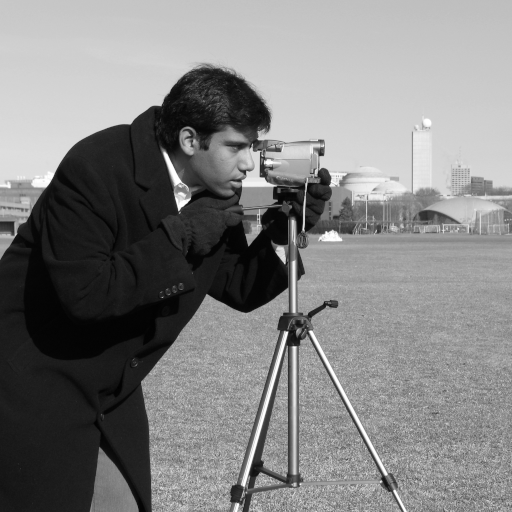

In [47]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera())
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [48]:
# Get the size of the image
width, height = img.size
# scaling factors
cX = 2
cY = 2

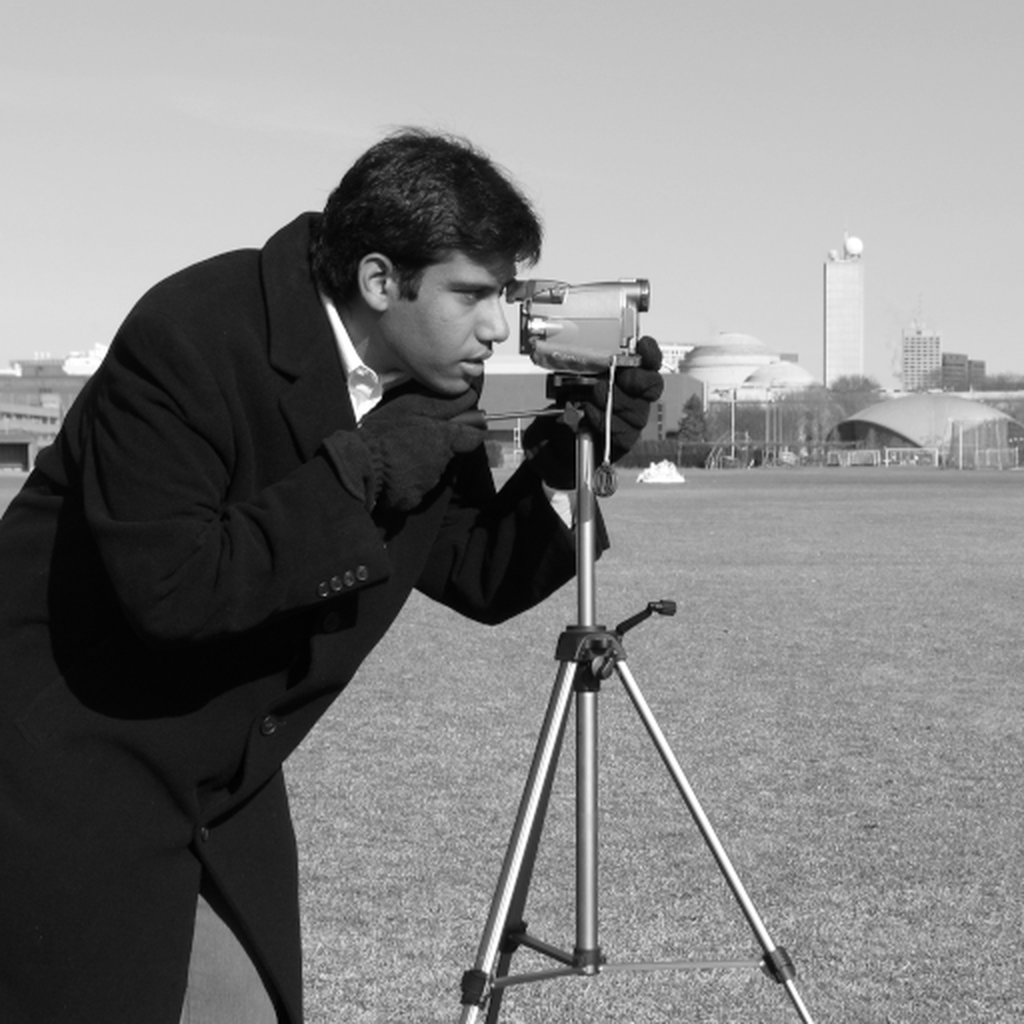

In [49]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * cX)
new_height = int(height * cY)
# Resize the image using PIL's built-in method
scaled = img.resize((new_width, new_height), Image.LANCZOS)
scaled

In [50]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [51]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

In [52]:
nonuniform_img = img.resize(
    (new_width, new_height),
    Image.LANCZOS
)

Original size: (512, 512)
Non-uniform size: (1024, 512)


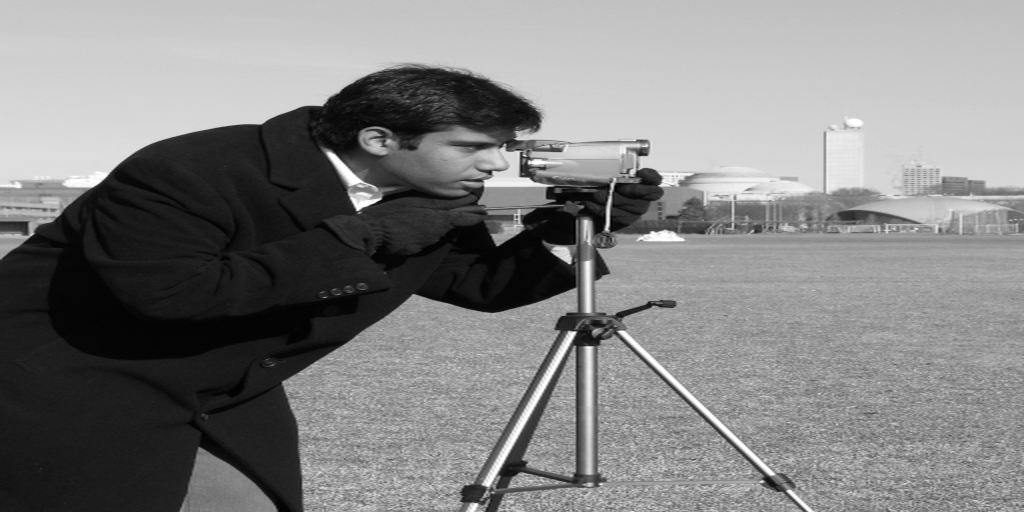

In [53]:
nonuniform_img.save("task1_1_non_uniform.jpg")

print("Original size:", img.size)
print("Non-uniform size:", nonuniform_img.size)
nonuniform_img


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


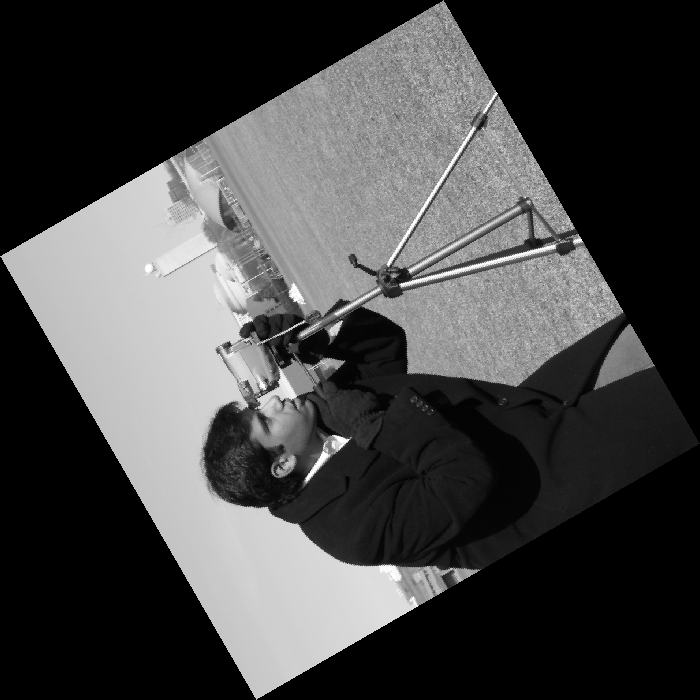

In [54]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

Rotated = img.rotate(
    120,
    expand=True)

Rotated.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", Rotated.size)

Rotated


### 3. Shear

In [55]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [56]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear = 0.5
shx = shear
shy = 0

new_width = int(width + abs(shx * height))
new_height = height

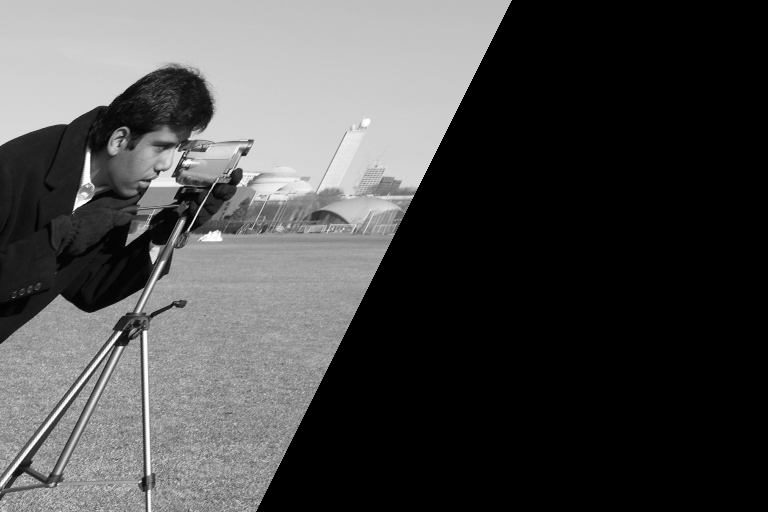

In [57]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.BICUBIC
)

sheared

In [58]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")

sheared.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared.size)


Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

Shear: 0.1


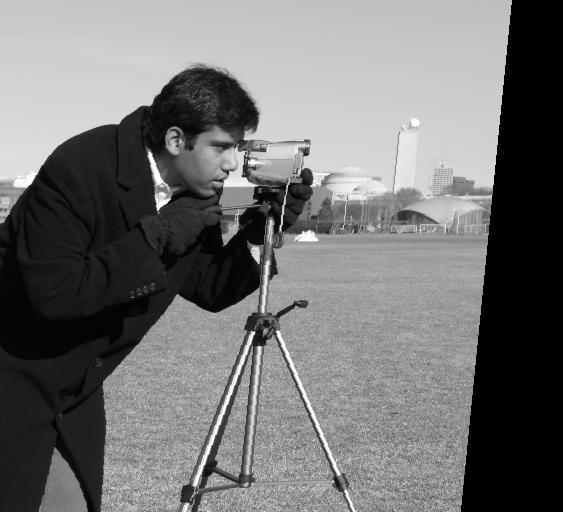

Shear: 0.3


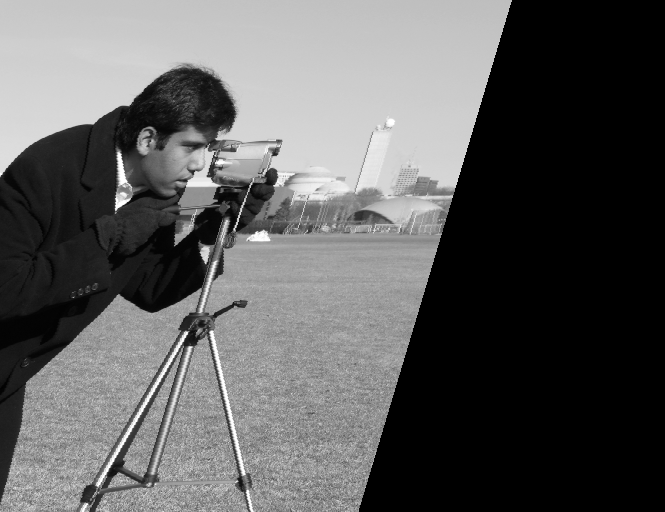

Shear: 0.5


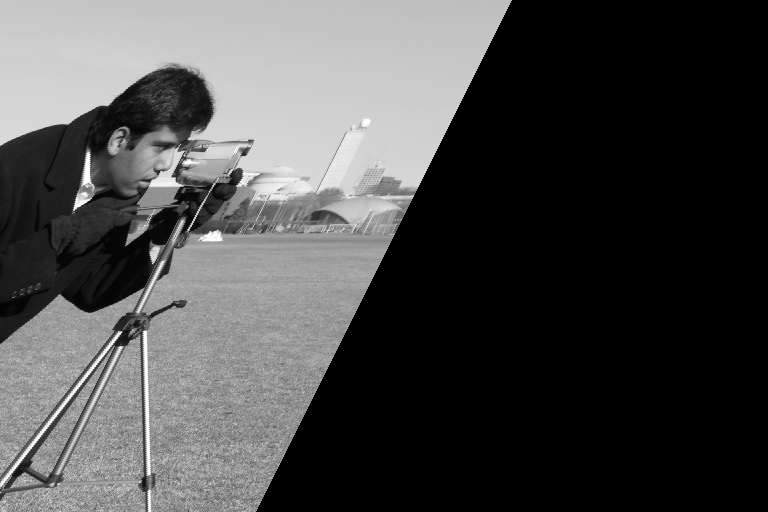

Shear: 0.8


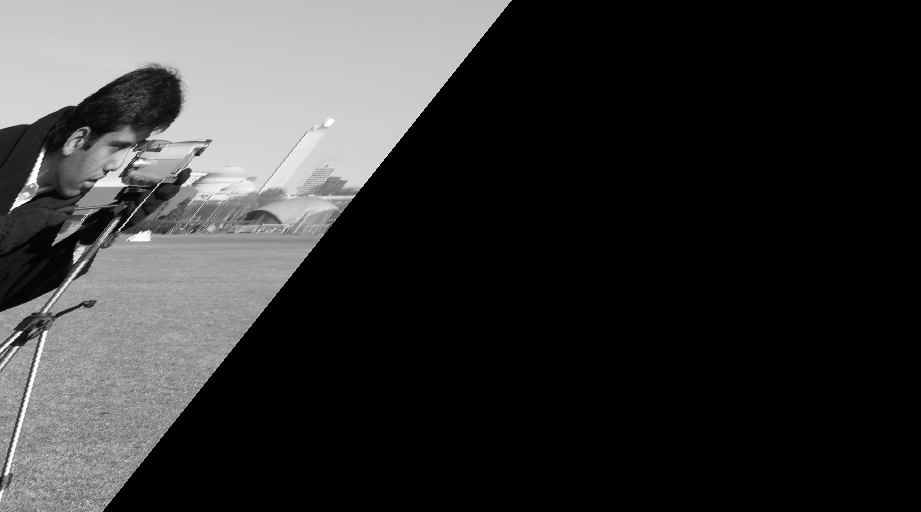

In [59]:
# Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

for shear in [0.1, 0.3, 0.5, 0.8]:
    shx = shear
    shy = 0

    new_width = int(width + abs(shx * height))

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, shx, 0, shy, 1, 0)
    )

    print("Shear:", shear)
    display(result)

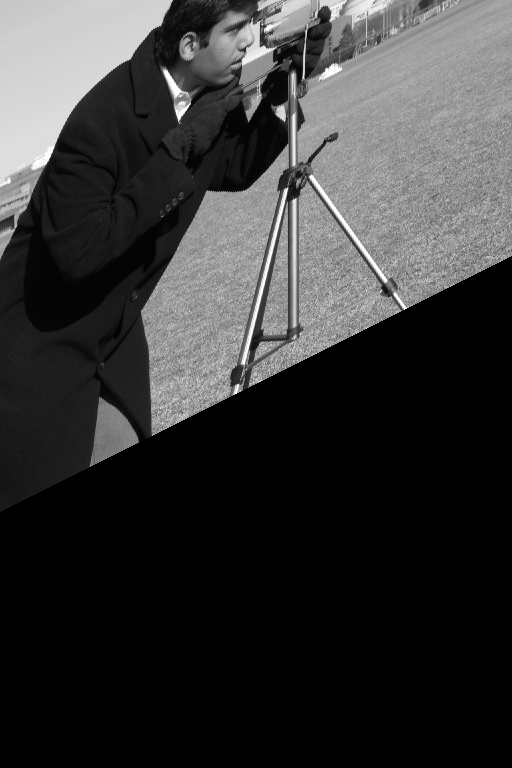

In [60]:
# Switch from X-axis to Y-axis shear matrix

shear = 0.5
shx = 0
shy = shear

new_height = int(height + abs(shy * width))

result_y = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0)
)

display(result_y)

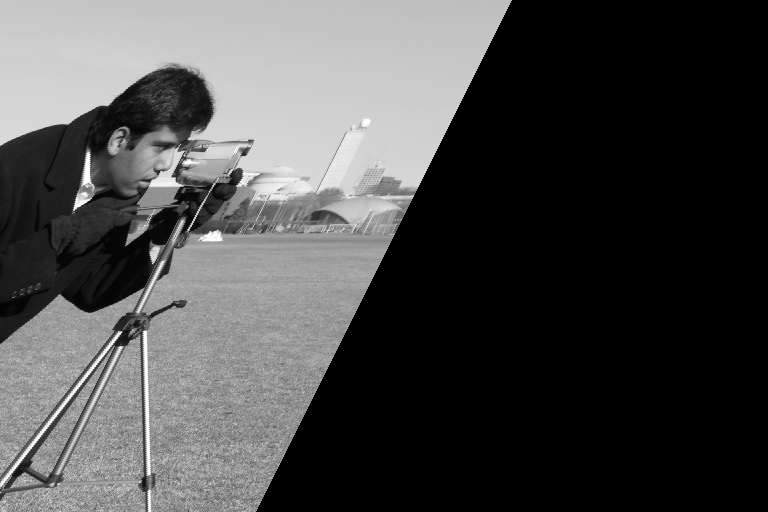

In [61]:
# Update the canvas multiplier to match your new factor

shear = 0.5
shx = shear
shy = 0

new_width = int(width + abs(shx * height))

result_canvas = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0)
)

display(result_canvas)

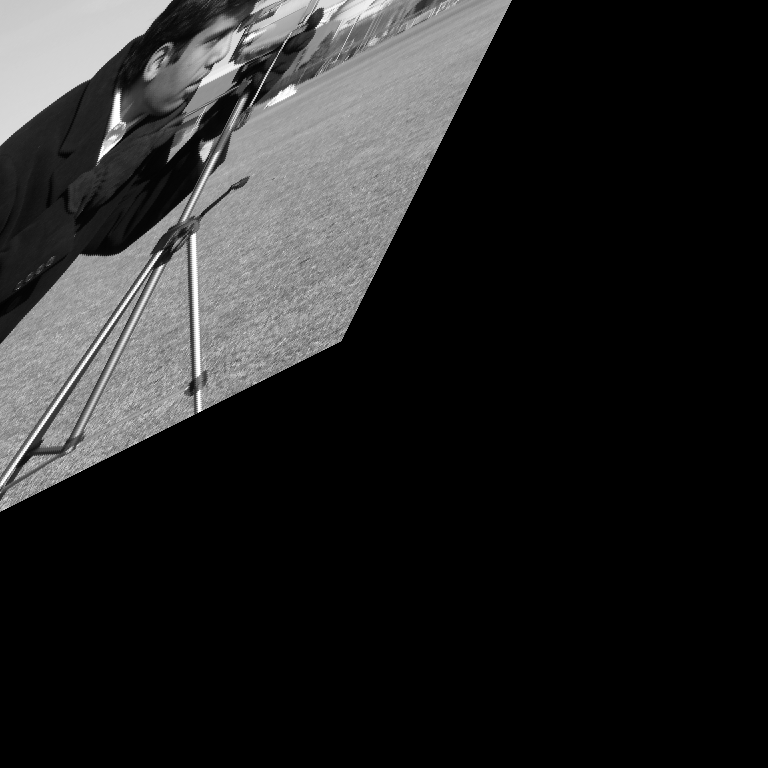

In [62]:
# Try combining X and Y shear in one matrix

shx = 0.5
shy = 0.5

new_width = int(width + abs(shx * height))
new_height = int(height + abs(shy * width))

result_xy = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0)
)

display(result_xy)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

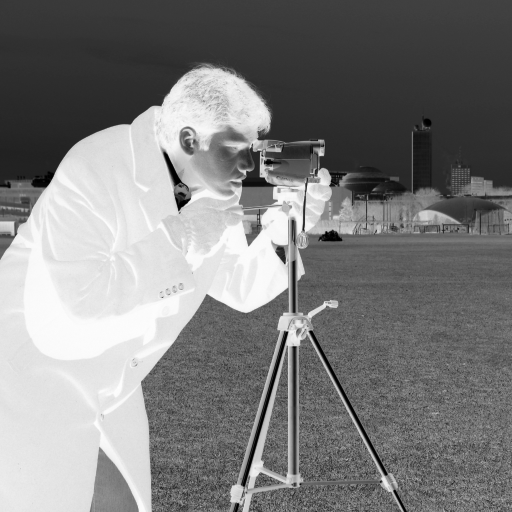

In [63]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr)

negative_img.save("negative_numpy.jpg")

negative_img

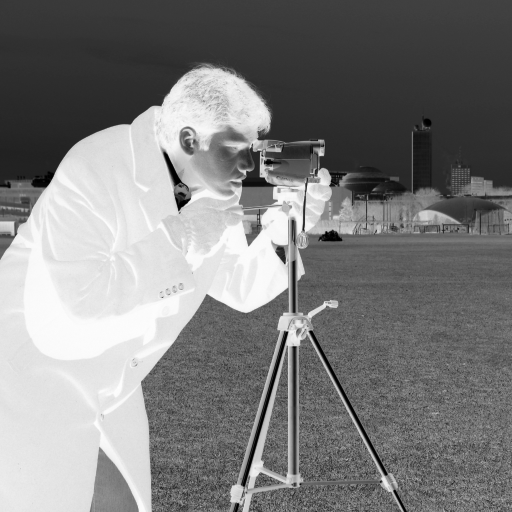

In [64]:
# Method 2: PIL's ImageOps

negative_pil = ImageOps.invert(img)
negative_pil


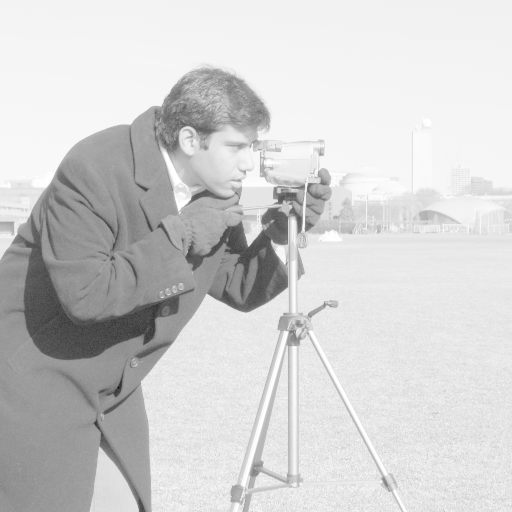

In [65]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel

arr = np.array(img, dtype=np.float32)
c = 255 / np.log(1 + 255)
log_transformed_arr = c * np.log(1 + arr)
log_img = Image.fromarray(log_transformed_arr.astype(np.uint8))
log_img


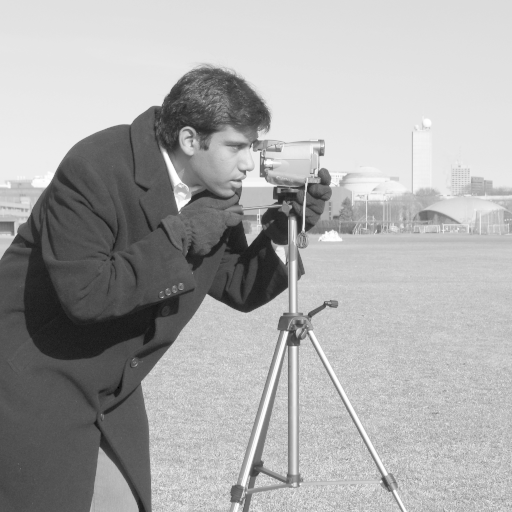

In [66]:

# ── 3. Power-law / Gamma correction ───────────────

arr = np.array(img, dtype=np.float64) / 255.0
gamma = 0.5
gamma_corrected_arr = np.power(arr, gamma) * 255.0
gamma_img = Image.fromarray(np.uint8(gamma_corrected_arr))
gamma_img


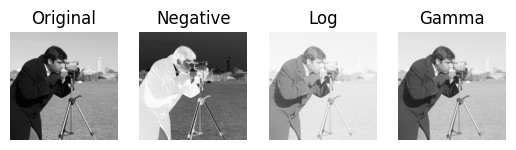

In [67]:
plt.subplot(1, 4, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 4, 2), plt.imshow(negative_img, cmap='gray'), plt.title('Negative'), plt.axis('off')
plt.subplot(1, 4, 3), plt.imshow(log_img, cmap='gray'), plt.title('Log'), plt.axis('off')
plt.subplot(1, 4, 4), plt.imshow(gamma_img, cmap='gray'), plt.title('Gamma'), plt.axis('off')
plt.show()